Title: Policy and Flow


## Headline 1: Inflation and unemployment as push factors



In [1]:
import pandas as pd

# Load dataset (skip metadata rows)
infl = pd.read_csv("/Users/zaangwenya/Documents/finalised_data_science_lab/DataScienceLab_Migration/data_raw/Inflation Consumer Prices.csv", skiprows=4)

# Keep only Nigeria
infl_ng = infl[infl["Country Name"] == "Nigeria"]

# Drop unnecessary columns
infl_ng = infl_ng.drop(columns=["Country Code", "Indicator Name", "Indicator Code"])

# Convert from wide → long format
infl_long = infl_ng.melt(
    id_vars=["Country Name"],
    var_name="Year",
    value_name="Inflation"
)

# Clean data
infl_long["Year"] = pd.to_numeric(infl_long["Year"], errors="coerce")
infl_long["Inflation"] = pd.to_numeric(infl_long["Inflation"], errors="coerce")

# Remove missing values
infl_long = infl_long.dropna()

infl_long = infl_long[infl_long["Year"] >= 2000]

# Sort by year
infl_long = infl_long.sort_values("Year")

# Save clean file
infl_long.to_csv("nigeria_inflation_clean.csv", index=False)

print(infl_long.head())

   Country Name    Year  Inflation
40      Nigeria  2000.0   6.933292
41      Nigeria  2001.0  18.873646
42      Nigeria  2002.0  12.876579
43      Nigeria  2003.0  14.031784
44      Nigeria  2004.0  14.998034


⬆:This script cleans Nigerian inflation data for easier analysis. It removes unnecessary metadata and reshapes the dataset from wide to long format using the melt function ensuring all values are numeric. It also filters the data from the year 2000 onwards and sorts it chronologically. The same cleaning approach can also be applied to unemployment and labor force datasets since they come from the same source(The World Bank).

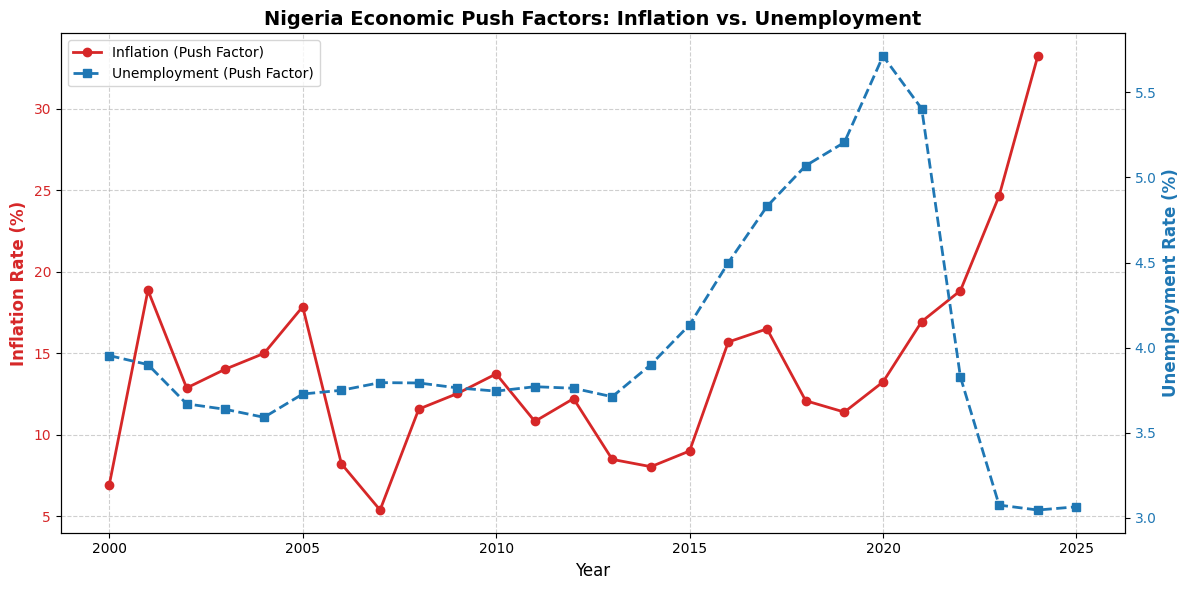

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the data from your CSV files
# Ensure the file names below match your actual filenames exactly
try:
    df_inf = pd.read_csv('/Users/zaangwenya/Documents/finalised_data_science_lab/DataScienceLab_Migration/data_processed/clean_in.csv')
    df_unemp = pd.read_csv('/Users/zaangwenya/Documents/finalised_data_science_lab/DataScienceLab_Migration/data_processed/clean_un.csv')
except FileNotFoundError:
    print("Error: Ensure your CSV files are in the same folder as this script.")

# 2. Setup the figure and the first axis (Inflation)
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Inflation (Primary Y-Axis)
color_inf = 'tab:red'
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Inflation Rate (%)', color=color_inf, fontsize=12, fontweight='bold')
ax1.plot(df_inf['Year'], df_inf['Inflation Rate'], color=color_inf, marker='o', label='Inflation (Push Factor)', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color_inf)
ax1.grid(True, linestyle='--', alpha=0.6)

# 3. Setup the second axis (Unemployment)
ax2 = ax1.twinx()
color_unemp = 'tab:blue'
ax2.set_ylabel('Unemployment Rate (%)', color=color_unemp, fontsize=12, fontweight='bold')
ax2.plot(df_unemp['Year'], df_unemp['Unemployment Rate'], color=color_unemp, marker='s', label='Unemployment (Push Factor)', linewidth=2, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color_unemp)

# 4. Final touches
plt.title('Nigeria Economic Push Factors: Inflation vs. Unemployment', fontsize=14, fontweight='bold')
fig.tight_layout()

# Add a combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# 5. Display the graph
plt.show()


⬆:This graph visualizes the relationship between Nigeria's Inflation Rate (red solid line) and Unemployment Rate (blue dashed line) from 2000 to 2025. It employs a dual-axis design to manage the different scales of the two metrics, with inflation measured on the left axis and unemployment on the right.


For the first fifteen years (2000–2015), both indicators fluctuated within a relatively stable range: inflation generally stayed between 5% and 20%, while unemployment remained low and steady, hovering near 4%. However, the period after 2015 marks a significant shift in economic stability. Unemployment saw a dramatic surge, peaking at nearly 5.8% around 2020 before experiencing a sharp decline toward 3% by 2023.


In contrast, inflation has followed an aggressive upward trajectory in recent years. While it dipped slightly around 2020, it skyrocketed after 2021, breaking past 30% by 2024. This creates a striking divergence in the final years of the plot: as unemployment figures appear to have stabilized at a historic low, inflation has surged to a historic high, suggesting that soaring costs of living have replaced job availability as the primary economic "push factor" for the country.

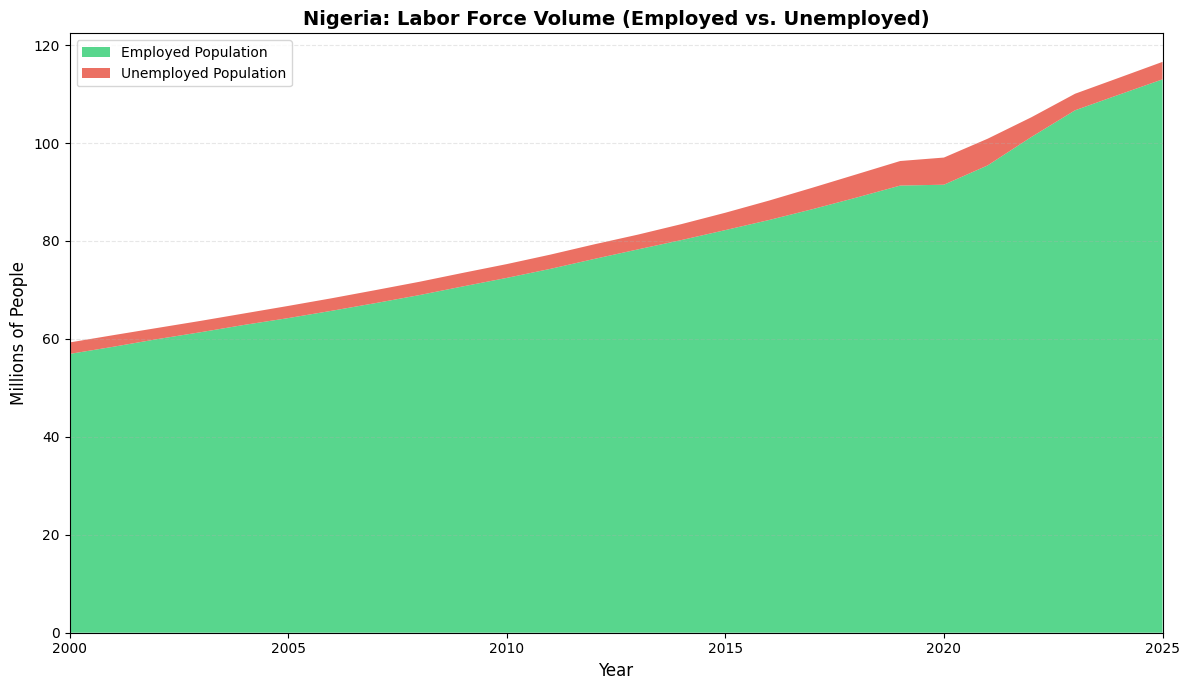

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load Labor Force data
df_total = pd.read_csv('/Users/zaangwenya/Documents/finalised_data_science_lab/DataScienceLab_Migration/data_processed/clean_labor_force.csv')
df_total.columns = df_total.columns.str.strip()  # remove extra spaces

# Filter for Nigeria
df_ng_total = df_total[df_total['Country Name'] == 'Nigeria'].copy()

# Ensure 'Year' is numeric
df_ng_total['Year'] = pd.to_numeric(df_ng_total['Year'])

# 2. Load Unemployment Rate data
df_unemp = pd.read_csv('/Users/zaangwenya/Documents/finalised_data_science_lab/DataScienceLab_Migration/data_processed/clean_un.csv')
df_unemp.columns = df_unemp.columns.str.strip()
df_unemp['Year'] = pd.to_numeric(df_unemp['Year'])

# 3. Merge datasets on 'Year'
df_combined = pd.merge(df_ng_total, df_unemp, on='Year')

# 4. Calculate Employed and Unemployed counts
df_combined['Unemployed_Count'] = (df_combined['Unemployment Rate'] / 100) * df_combined['Total_Labor_Force']
df_combined['Employed_Count'] = df_combined['Total_Labor_Force'] - df_combined['Unemployed_Count']

# 5. Plot Stacked Area Chart
plt.figure(figsize=(12, 7))

plt.stackplot(
    df_combined['Year'],
    df_combined['Employed_Count'] / 1e6,
    df_combined['Unemployed_Count'] / 1e6,
    labels=['Employed Population', 'Unemployed Population'],
    colors=['#2ecc71', '#e74c3c'],
    alpha=0.8
)

plt.title('Nigeria: Labor Force Volume (Employed vs. Unemployed)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Millions of People', fontsize=12)
plt.xlim(df_combined['Year'].min(), df_combined['Year'].max())
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

⬆:This stacked area chart provides a comprehensive look at Nigeria's growing labor force from 2000 to 2025, but its visual representation of employment (the green area) requires a critical economic lens to understand the reality on the ground. At a glance, the total labor force shows a massive, steady expansion, nearly doubling from 60 million to over 110 million people, which illustrates the country's significant demographic youth bulge. While the red area representing unemployment appears to shrink significantly after 2020, this trend is largely a reflection of a controversial shift in data methodology rather than a sudden abundance of high quality jobs.


The sharp drop in the red unemployed section corresponds with the 1-hour working rule adopted by the National Bureau of Statistics (NBS) in 2023 to align with International Labour Organization (ILO) standards. Under this definition, anyone who engages in at least one hour of economic activity for pay or profit in the preceding seven days is classified as "employed". This includes everything from small scale trade and subsistence farming to running minor errands. Consequently, the vast green area on the chart masks a deep seated crisis of underemployment and working poverty, where millions are technically employed but earn far too little to survive amidst Nigeria's triple digit inflation and a depreciated Naira.


This disconnect between statistical employment and economic stability is the primary driver of the "Japa" phenomenon, where skilled and unskilled Nigerians alike seek work elsewhere. Even though the chart shows a large employed population, the economy remains volatile due to soaring fuel prices, a high misery index, and a cost of living crisis that has outpaced the new minimum wage. For many represented in that green area, employment does not mean a stable career or financial security, instead, it represents a survival struggle that pushes them to look for better opportunities beyond Nigeria's borders.
